<a href="https://www.kaggle.com/code/samratrm/student-health-risk-classification-using-knn?scriptVersionId=338119045" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Student Health Risk Classification: KNN Model & 2D Manifold Analysis



#### 🩺 Student Health Risk Classification: KNN + High-Dimensional UMAP

Welcome! This notebook predicts student health risk categories (**`unhealthy`**, **`at-risk`**, **`fit`**) across a dataset of **50,000 college students** using K-Nearest Neighbors and 2D manifold projections.

#### 🔍 What to Look For

* **Feature Pipeline:** Standardized numeric features and encoded ordinal/nominal indicators (sleep, heart rate, BMI, stress, activity level) across 15 total dimensions.
* **Tuned KNN Model:** Optimized via `RandomizedSearchCV` ($k=6$, Euclidean distance weighting) to effectively handle class imbalanced boundaries.
* **2D UMAP Projection:** Uses custom high-contrast neon palettes (`#ff0055`, `#cbd5e1`, `#00e676`) to visually isolate minority health groups (`fit` & `unhealthy`) from the majority `at-risk` cluster.

#### 🚀 Performance Highlights

| Metric | Score | Key Takeaway |
| --- | --- | --- |
| **Test Accuracy** | **94.87%** | High overall predictive precision across 10,000 test samples. |
| **Macro F1-Score** | **0.8401** | Strong balanced performance across both majority and minority classes. |
| **Macro ROC-AUC** | **0.9842** | Exceptional class separation confidence across threshold boundaries. |

*Scroll down to check out the confusion matrix and explore the 2D UMAP cluster map!*

In [1]:
import numpy as np
import pandas as pd
import kagglehub
import os
import sklearn 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/enhanced_student_health_dataset_50k.xls
/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/student_health_dataset_50k.csv


In [3]:
df = pd.read_csv("/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/student_health_dataset_50k.csv")
df.head()

,student_id,timestamp,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,health_condition
0,1102,2025-01-01 00:00:00,9.29,67.4,28.56,2113.0,5227,91.3,2.08,veg,high,average,active,yes,other,at-risk
1,1435,2025-01-01 01:00:00,9.33,57.2,30.17,2060.0,14460,67.0,2.57,veg,medium,average,active,occasional,male,at-risk
2,1860,2025-01-01 02:00:00,8.33,73.7,19.93,2236.0,14589,52.6,1.93,non-veg,high,average,active,no,other,at-risk
3,1270,2025-01-01 03:00:00,5.60,61.9,22.02,2650.0,12618,55.2,2.97,veg,high,average,active,no,other,unhealthy
4,1106,2025-01-01 04:00:00,9.10,69.6,20.85,1985.0,14518,27.1,3.09,non-veg,medium,poor,sedentary,occasional,male,at-risk


In [4]:
df.shape

(50000, 16)

In [5]:
df.isna().sum()

student_id                 0
timestamp                  0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
health_condition           0
dtype: int64

In [6]:
df.shape

(50000, 16)

In [7]:
df['health_condition'].value_counts()

health_condition
at-risk      43718
unhealthy     3816
fit           2466
Name: count, dtype: int64

In [8]:
df[df.select_dtypes("number").columns].head()

,student_id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
0,1102,9.29,67.4,28.56,2113.0,5227,91.3,2.08
1,1435,9.33,57.2,30.17,2060.0,14460,67.0,2.57
2,1860,8.33,73.7,19.93,2236.0,14589,52.6,1.93
3,1270,5.60,61.9,22.02,2650.0,12618,55.2,2.97
4,1106,9.10,69.6,20.85,1985.0,14518,27.1,3.09


## Preprocessing

In [9]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

def ordinal_encoding(X, ordinal_map):
    X_enc = X.copy()
    for col, mapping in ordinal_map.items():
        X_enc[col] = X_enc[col].map(mapping)
    print(X_enc.columns)
    return X_enc


In [10]:
from sklearn.model_selection import train_test_split

ordinal_mappings = {
            'stress_level': {'low': 0, 'medium': 1, 'high': 2},
            'sleep_quality': {'poor': 0, 'average': 1, 'good': 2},
            'physical_activity_level': {'sedentary': 0, 'moderate': 1, 'active': 2},
            'smoking_alcohol': {'no': 0, 'occasional': 1, 'yes': 2}
        }

nominal_cols = ["gender", "diet_type"]
ordinal_cols = ["stress_level", "sleep_quality", "physical_activity_level", "smoking_alcohol"]
categories_order = ['unhealthy', 'at-risk', 'fit']
num_cols = [
        'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
        'step_count', 'exercise_duration', 'water_intake'
    ]

def preprocess(df: pd.DataFrame, target_col:str):

    df = df.copy()

    # Target Encoding
    encoder = OrdinalEncoder(categories=[categories_order])
    y = encoder.fit_transform(df[[target_col]]).ravel().astype(int)

    # Drop non feature column
    X = df.drop(columns=[target_col])
    if 'student_id' in X.columns:
            X = X.drop(columns=['student_id'])
    if 'timestamp' in X.columns:
        X = X.drop(columns=['timestamp'])    

    # Ordinal Enc 
    X_ord = ordinal_encoding(X, ordinal_mappings)

    # train / Test split 
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_ord, y, stratify=y, test_size=0.2, random_state=42)

    
    ct = ColumnTransformer(
        transformers = [
            ("scaler", StandardScaler(), num_cols + ordinal_cols),
            ("ohe", OneHotEncoder(drop="first", sparse_output=False), nominal_cols)
        ]
    )

    X_train_transformed = ct.fit_transform(X_train_raw)
    X_test_transformed = ct.transform(X_test_raw)

    feature_names = ct.get_feature_names_out()
    X_train = pd.DataFrame(X_train_transformed, columns=feature_names)
    X_test = pd.DataFrame(X_test_transformed, columns=feature_names)
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = preprocess(df, "health_condition")

print(f"Encoded columns: {X_train.columns.to_list()}, \n Training data shape: {X_train.shape}, \n Testing data shape: {X_test.shape}")

Index(['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake', 'diet_type',
       'stress_level', 'sleep_quality', 'physical_activity_level',
       'smoking_alcohol', 'gender'],
      dtype='object')
Encoded columns: ['scaler__sleep_duration', 'scaler__heart_rate', 'scaler__bmi', 'scaler__calorie_expenditure', 'scaler__step_count', 'scaler__exercise_duration', 'scaler__water_intake', 'scaler__stress_level', 'scaler__sleep_quality', 'scaler__physical_activity_level', 'scaler__smoking_alcohol', 'ohe__gender_male', 'ohe__gender_other', 'ohe__diet_type_non-veg', 'ohe__diet_type_veg'], 
 Training data shape: (40000, 15), 
 Testing data shape: (10000, 15)


## KNN with stratified K-Fold CV & Hyperparam Tuning

In [11]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "n_neighbors": [3,6,10,15,21,35,51,75],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn = KNeighborsClassifier()

grid_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_grid,
    cv=skf,
    n_iter=10,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n --- Cross Validation Results ---\n")
print(f"Best Hyperparams : {grid_search.best_params_}")
print(f"Best Stratified CV Macro F1-Score: {grid_search.best_score_:.4f}")

# Final Model 
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)

print("\n --- Test Set Performance --- \n") 
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test,y_pred, target_names=categories_order))

Fitting 5 folds for each of 10 candidates, totalling 50 fits

 --- Cross Validation Results ---

Best Hyperparams : {'weights': 'uniform', 'n_neighbors': 6, 'metric': 'manhattan'}
Best Stratified CV Macro F1-Score: 0.8388

 --- Test Set Performance --- 

Accuracy: 0.9514

              precision    recall  f1-score   support

   unhealthy       0.87      0.75      0.80       763
     at-risk       0.96      0.99      0.97      8744
         fit       0.96      0.60      0.74       493

    accuracy                           0.95     10000
   macro avg       0.93      0.78      0.84     10000
weighted avg       0.95      0.95      0.95     10000



## Metrics Evaluation

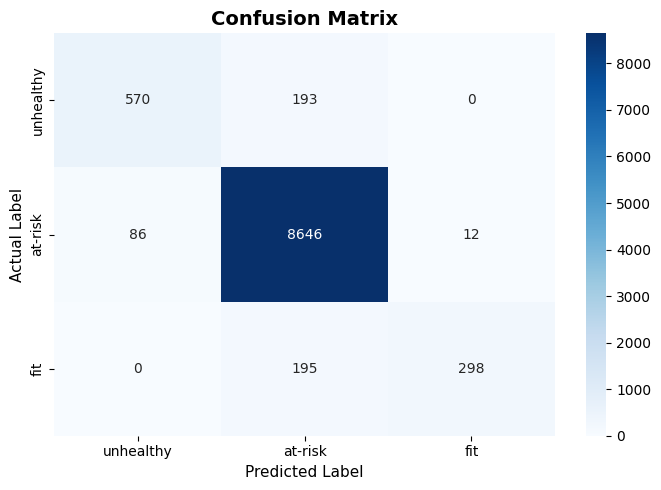

In [12]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels=categories_order):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm, 
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels
    )
    
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('Actual Label', fontsize=11)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred)

**Note:**

Cohen’s Kappa measures how well your model agrees with actual labels beyond pure random guessing. While standard accuracy can look artificially high on imbalanced datasets, Kappa checks if the model actually learned the classes or is just getting lucky.

Scale: $-1$ to $1$

$1.0$ = Perfect agreement

$0.0$ = Performance is no better than random guessing 

$< 0$ = Worse than random chance.

In [13]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa Score: {kappa:.4f}")

Cohen's Kappa Score: 0.7612


In [14]:
from sklearn.metrics import balanced_accuracy_score

bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {bal_acc:.4f}")

Balanced Accuracy: 0.7801


In [15]:
from sklearn.metrics import roc_auc_score

y_probs = best_knn.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_probs, multi_class='ovr', average='macro')
print(f"Macro One-vs-Rest ROC-AUC Score: {roc_auc:.4f}")

Macro One-vs-Rest ROC-AUC Score: 0.9858


In [16]:
from sklearn.metrics import log_loss

loss = log_loss(y_test, y_probs)
print(f"Log Loss: {loss:.4f}")

Log Loss: 0.1533


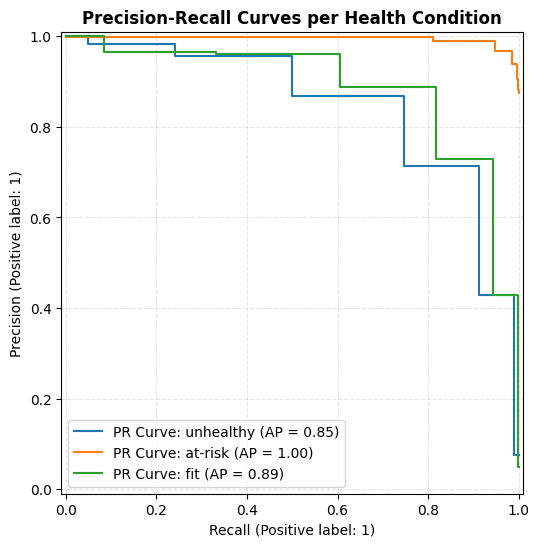

In [17]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(8, 6))
for i, class_name in enumerate(categories_order):
    PrecisionRecallDisplay.from_predictions(
        (y_test == i).astype(int),
        y_probs[:, i],
        name=f"PR Curve: {class_name}",
        ax=ax
    )

plt.title("Precision-Recall Curves per Health Condition", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

In [18]:
def plot_map_viz(plot_df, x, y, title, x_label, y_label, legend_title):
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=plot_df,
        x=x,
        y=y,
        hue='Health Condition',
        hue_order=['unhealthy', 'at-risk', 'fit'],
        palette = {'unhealthy': '#ff0055','at-risk':'#cbd5e1','fit':'#00e676'},
        alpha=0.6,
        s=25
    )
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(x_label, fontsize=11)
    plt.ylabel(y_label, fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(title=legend_title, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [19]:
!pip install umap-learn

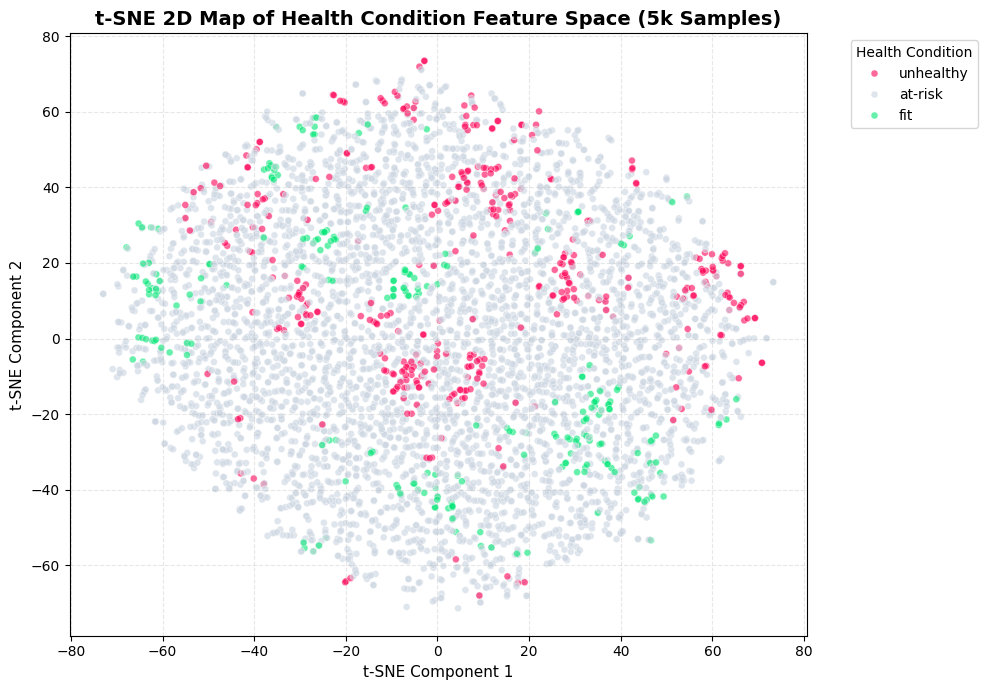

In [20]:
from sklearn.manifold import TSNE

y_train_labels = pd.Series(y_train).map({0: 'unhealthy', 1: 'at-risk', 2: 'fit'})

X_tsne_sample = X_train.sample(n=5000, random_state=42)
y_tsne_sample = y_train_labels.loc[X_tsne_sample.index]

tsne = TSNE(
    n_components=2, 
    perplexity=30, 
    learning_rate='auto', 
    init='pca', 
    random_state=42, 
    n_jobs=-1
)
X_tsne = tsne.fit_transform(X_tsne_sample)

tsne_df = pd.DataFrame({
    't-SNE 1': X_tsne[:, 0],
    't-SNE 2': X_tsne[:, 1],
    'Health Condition': y_tsne_sample
})

# Call plot function for t-SNE
plot_map_viz(
    plot_df=tsne_df,
    x='t-SNE 1',
    y='t-SNE 2',
    title='t-SNE 2D Map of Health Condition Feature Space (5k Samples)',
    x_label='t-SNE Component 1',
    y_label='t-SNE Component 2',
    legend_title='Health Condition'
)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


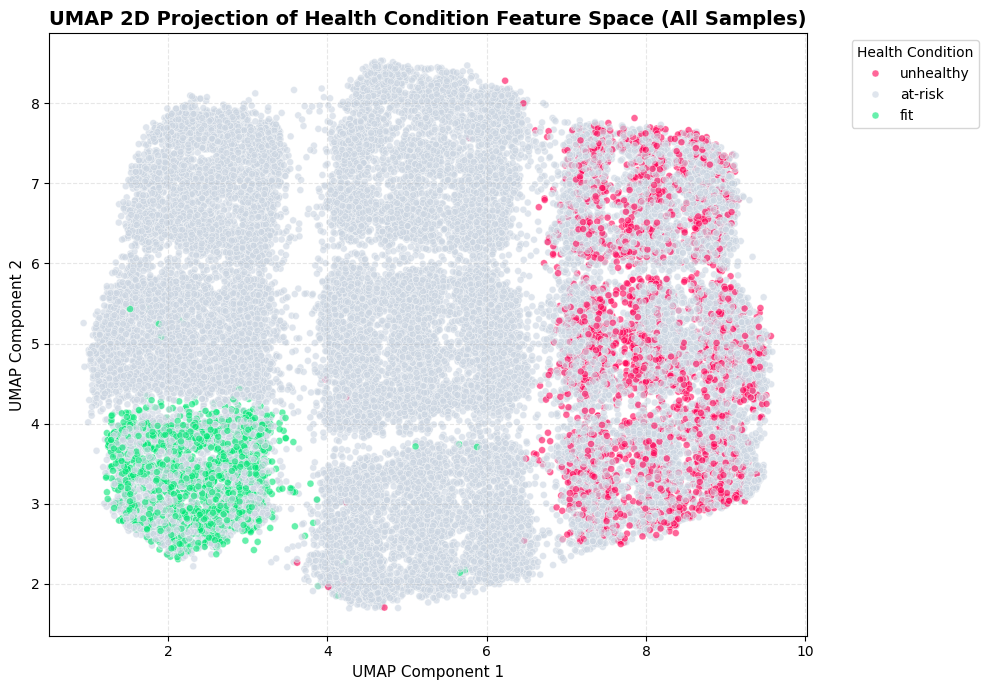

In [21]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=42,
    n_jobs=-1
)

X_umap = reducer.fit_transform(X_train)

umap_df = pd.DataFrame({
    'UMAP 1': X_umap[:, 0],
    'UMAP 2': X_umap[:, 1],
    'Health Condition': y_train_labels
})

plot_map_viz(
    plot_df=umap_df,
    x='UMAP 1',
    y='UMAP 2',
    title='UMAP 2D Projection of Health Condition Feature Space (All Samples)',
    x_label='UMAP Component 1',
    y_label='UMAP Component 2',
    legend_title='Health Condition'
)